In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from GB84 import variables, rho_m, v,cloud_heights, h_out, phi, f, non_dim_numbers
from kalman_filter import kalman_filter as kf
from scipy import signal
from scipy.stats import pearsonr

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
slice_str = "2024-07-01 00:00:00, 2024-07-31 23:59:00"
slice_tuple = tuple(slice_str.split(", "))

### Testing the model

In [3]:
measurements = xr.open_mfdataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')

In [4]:
measurements

<xarray.Dataset> Size: 411kB
Dimensions:          (time: 4464, day_in_time_interval: 31, nv: 2)
Coordinates:
  * time             (time) datetime64[ns] 36kB 2024-07-01 ... 2024-07-31T23:...
Dimensions without coordinates: day_in_time_interval, nv
Data variables: (12/22)
    iso_dataset      |S1 1B ...
    product          |S1 1B ...
    station_details  |S1 1B ...
    date             (time) int32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    valid_dates      (day_in_time_interval) int8 31B dask.array<chunksize=(31,), meta=np.ndarray>
    time_bnds        (time, nv) datetime64[ns] 71kB dask.array<chunksize=(4464, 2), meta=np.ndarray>
    ...               ...
    F010             (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    IF010            (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    D010             (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    ID010            (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    TD002            (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    RH002            (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
Attributes:
    institution:              Royal Netherlands Meteorological Institute (KNMI)
    comment:                  none
    Conventions:              CF-1.4
    location:                 CESAR observatory, the Netherlands
    file_creation_date_time:  20240826 10:49:12 (UTC)
    references:               cesar_surface_meteo_lc1_t10_v1.0.pdf @ http://w...
    history:                  Continuous observations are performed, gap fill...

#### Radiometer LWC 

In [5]:
cabaw = xr.open_mfdataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\data\Cabaw_radiometer\*.nc')
reference_date = np.datetime64("2024-07-01")

# Convert minutes into datetime
#datetime_values = reference_date + measurements.time.astype("timedelta64[m]")
#measurements['time'] = datetime_values

july = cabaw.sel(time=slice('2024-07-01', '2024-08-01'))

In [6]:
july

<xarray.Dataset> Size: 57MB
Dimensions:       (time: 1794345)
Coordinates:
  * time          (time) datetime64[ns] 14MB 2024-07-01 ... 2024-08-01T23:59:59
Data variables:
    iwv           (time) float32 7MB dask.array<chunksize=(75427,), meta=np.ndarray>
    lwp           (time) float32 7MB dask.array<chunksize=(75427,), meta=np.ndarray>
    zenith_angle  (time) float32 7MB dask.array<chunksize=(75427,), meta=np.ndarray>
    latitude      (time) float32 7MB 51.97 51.97 51.97 ... 51.97 51.97 51.97
    longitude     (time) float32 7MB 4.927 4.927 4.927 ... 4.927 4.927 4.927
    altitude      (time) float32 7MB -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0 -1.0
Attributes: (12/15)
    Conventions:                  CF-1.8
    cloudnetpy_version:           1.61.12
    file_uuid:                    1737a835-5c0c-467b-a2e0-01574fd7961d
    cloudnet_file_type:           mwr
    title:                        HATPRO microwave radiometer from Cabauw
    year:                         2024
    ...                           ...
    history:                      2024-06-02 00:39:31 +00:00 - mwr file created
    source:                       RPG-Radiometer Physics HATPRO
    references:                   https://doi.org/10.21105/joss.02123
    instrument_pid:               https://hdl.handle.net/21.12132/3.c28c803c7...
    cloudnet_processing_version:  2.36.1
    pid:                          https://hdl.handle.net/21.12132/1.1737a8355...

In [7]:
#var = ['temperature','pressure','humidity','rain_rate']
var = ['TA002','P0','TD002','RH002']
measurements = measurements[var]
measurements = measurements.dropna(dim='time',how='any')

measurements_used = measurements.sel(time=slice(*slice_tuple))

In [8]:
measurements

<xarray.Dataset> Size: 107kB
Dimensions:  (time: 4464)
Coordinates:
  * time     (time) datetime64[ns] 36kB 2024-07-01 ... 2024-07-31T23:49:59.92...
Data variables:
    TA002    (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    P0       (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    TD002    (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    RH002    (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
Attributes:
    institution:              Royal Netherlands Meteorological Institute (KNMI)
    comment:                  none
    Conventions:              CF-1.4
    location:                 CESAR observatory, the Netherlands
    file_creation_date_time:  20240826 10:49:12 (UTC)
    references:               cesar_surface_meteo_lc1_t10_v1.0.pdf @ http://w...
    history:                  Continuous observations are performed, gap fill...

#Kalman filter measurements

kf_measurements = measurements['rain_rate'].values[7000:10000:30]

In [9]:
parsivel_1 = xr.open_dataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values

In [10]:
rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=measurements.time,method='nearest')

In [11]:
#kf_measurements = rain_rate.isel(time=slice(None, None, 6))
kf_measurements_used = rain_rate.sel(time=slice(*slice_tuple))

In [12]:
kf_measurements_used

<xarray.DataArray 'rainfall_rate_32bit' (time: 4464)> Size: 18kB
[4464 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[s] 36kB 2024-07-01 ... 2024-07-31T23:50:00
Attributes:
    long_name:  average rainfall rate over the last minute
    units:      mm/h
    comment:    Field 01 in technical documentation

#inputs

#temperature on the ground
T_surf_C = measurements_used['temperature'].values #[C]
T_surf = T_surf_C + 273.15    # [K]

#pressure
p_surf = measurements_used['pressure'].values*100  #[Pa]

#dew point temperature
RH = measurements_used['humidity'].values
alpha_T = 17.27*T_surf_C/(T_surf_C + 237.7) + np.log(RH/100) #from http://dx.doi.org/10.31648/ts.5425
T_d_arr = 237.7*alpha_T/(17.27 - alpha_T) + 273.15      #[K]

#state
X = np.zeros(len(T_surf))
X[0] = july.lwp[0]   #initial state in kg/m2
Sigma = np.zeros(len(T_surf))
Sigma[0] = 5 #initial state covariance in kg/m2

#timestep
dt= 600      #timestep in s

In [13]:
#inputs

#temperature on the ground
T_surf = measurements_used['TA002'].values #[K]


#pressure
p_surf = measurements_used['P0'].values*100  #[Pa]

#dew point temperature
T_d_arr = measurements_used['TD002'].values     #[K]

#state
X = np.zeros(len(T_surf))
X[0] = 0   #initial state in kg/m2
#X = july.lwp.sel(time=measurements_used.time,method='nearest').values
Sigma = np.zeros(len(T_surf))
Sigma[0] = 1 #initial state covariance in kg/m2

#timestep
dt= 600      #timestep in s

(19906.0, 19906.416666666668)

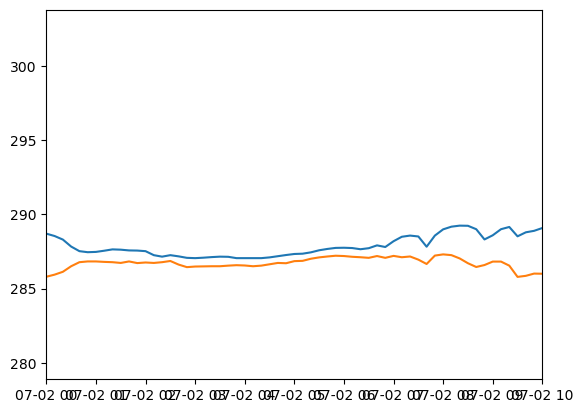

In [21]:
import datetime
plt.plot(measurements_used.time,T_surf)
plt.plot(measurements_used.time,T_d_arr)
x_start = datetime.datetime.fromisoformat('2024-07-02T00:00:00')
x_end = datetime.datetime.fromisoformat('2024-07-02T10:00:00')

plt.xlim(x_start, x_end)

In [16]:
measurements_used.time

<xarray.DataArray 'time' (time: 4464)> Size: 36kB
array(['2024-07-01T00:00:00.000000000', '2024-07-01T00:10:00.000017881',
       '2024-07-01T00:20:00.000035762', ..., '2024-07-31T23:30:00.000000000',
       '2024-07-31T23:40:00.073242187', '2024-07-31T23:49:59.926757812'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 36kB 2024-07-01 ... 2024-07-31T23:49:59.92...
Attributes:
    long_name:      hours since 2024-07-01 00:00:00 (UTC)
    standard_name:  time
    axis:           T
    bounds:         time_bnds

In [508]:
T_surf

array([287.07   , 286.81   , 286.72998, ..., 292.12   , 292.     ,
       291.83   ], dtype=float32)

In [509]:
RH = measurements_used['RH002'].values
T_surf_C =T_surf - 273.15
alpha_T = 17.27*T_surf_C/(T_surf_C + 237.7) + np.log(RH/100) #from http://dx.doi.org/10.31648/ts.5425
T_d_arr_2 = 237.7*alpha_T/(17.27 - alpha_T) + 273.15      #[K]

In [ ]:
#loop for finding the precipitation given the T_0 and p
P = np.zeros(len(T_surf))
P_0 = np.zeros(len(T_surf))
f_arr = np.zeros(len(T_surf))
h_arr = np.zeros(len(T_surf))
for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = variables(T_0, T_d, p_0, obs=False).run()
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
    
    #precipitation in kg/m2/s
    #P_0[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3
    
    #print(phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3600)
    #state without Kalman filter
    P_0[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3
    P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X[i]
    #print(T_s_up,T_m)
    #state with Kalman filter   
    if i>0:
         #if (i%18)==0:
             # we assume that we receive a precipitation update every 30mins
             #j = int(i/18)

             #if kf_measurements_used[j]>0:
                 #phi_kf = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()
                 #h_kf = h_out(v_updr,Z_c).run()[2]
                 #f_kf = f(T_d,p_0,p_t,T_t,rho,v_updr)
            
                 #kalman_f = kf(X[i-1], Sigma[i-1], dt,h_kf,phi_kf,f_kf,kf_measurements_used[j].values) 
                 #X[i],Sigma[i],X_apr = kalman_f.update()
                 #print(X[i],X_apr)
         #else:
             #if i<(len(T_surf)-1):

        if i<(len(T_surf)-1):
            X[i+1] = X[i] + dt*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X[i])
            Sigma[i+1] = Sigma[i]

        if (((i%18)==0)&(i>0)):
            # we assume that we receive a precipitation update every 60mins
            j = i
            print(j)
            
            phi_kf = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()
            h_kf = h_out(v_updr,Z_c).run()[2]
            f_kf = f(T_d,p_0,p_t,T_t,rho,v_updr)
            
            kalman_f = kf(X[i], Sigma[i], dt,h_kf,phi_kf,f_kf,kf_measurements_used[j].values) 
            X[i+1],Sigma[i+1],X_apr = kalman_f.update()

### Plots and results

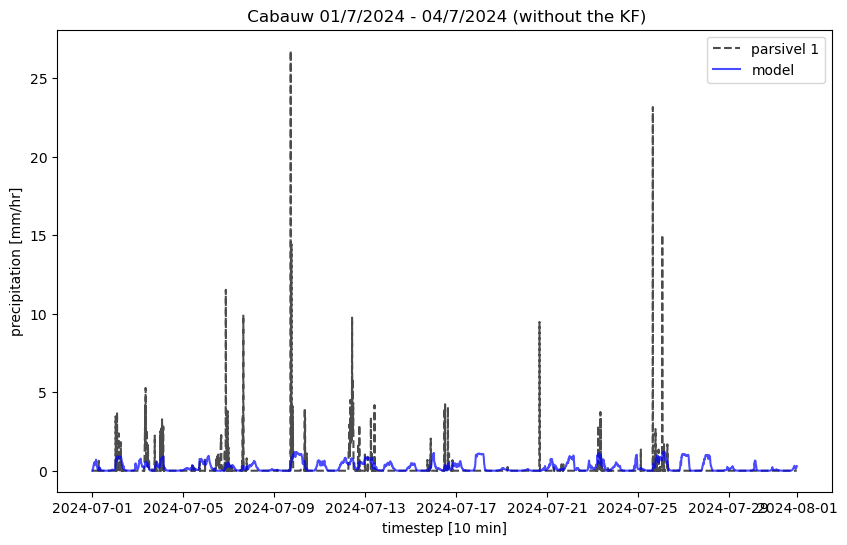

In [511]:
plt.figure(figsize=(10,6))
t_step = np.linspace(0,len(P),len(P))


#plt.plot(t_step,P_0*3600,label='model (steady state)')
plt.plot(measurements_used.time,rain_rate.sel(time=slice(*slice_tuple)),label='parsivel 1',color='black',alpha=0.7,linestyle='--') 
plt.plot(measurements_used.time,P*3600,label='model',color='blue',alpha=0.7)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
#plt.scatter(t_step[0::36],np.zeros((len(kf_measurements_used[0::36]))),label='kf update',marker='x',s=0.6,color='red')
plt.xlabel('timestep [10 min]')
plt.title(' Cabauw 01/7/2024 - 04/7/2024 (without the KF)')
plt.ylabel('precipitation [mm/hr]')
plt.legend()
#plt.grid()
plt.show()


(array([48., 38., 14., 14., 12., 13.,  7.,  9.,  8.,  7.,  5.,  7.,  4.,
         5.,  5.,  2.,  2.,  0.,  1.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,  0.,  0.,
         0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([ 0.38499999,  0.64863998,  0.91228002,  1.17592001,  1.43956006,
         1.70319998,  1.96684003,  2.23047996,  2.49412012,  2.75776005,
         3.02139997,  3.28504014,  3.54868007,  3.81231999,  4.07596016,
         4.33960009,  4.60324001,  4.86687994,  5.13051987,  5.39416027,
         5.6578002 ,  5.92144012,  6.18508005,  6.44871998,  6.71235991,
         6.97600031,  7.23964024,  7.50328016,  7.76692009,  8.030560

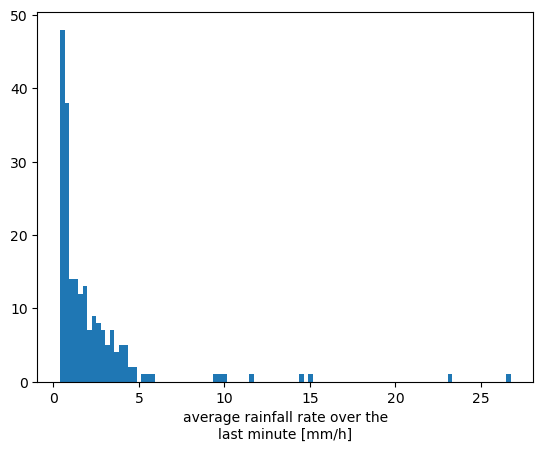

In [528]:
rain_rate.where(rain_rate>0.38).plot.hist(bins=100)

## Result analysis

In [588]:
np.sum((rain_rate>0.38))/len(rain_rate)

<xarray.DataArray 'rainfall_rate_32bit' ()> Size: 8B
array(0.04726703)

In [684]:
count_prec = np.sum((rain_rate>0.38) & (P*3600 > 0.25))
count_no_prec = np.sum((rain_rate==0) & (P*3600<0.25))
count_model_dubious = np.sum(
    (rain_rate> 0) & (rain_rate <= 0.38) & (P * 3600 < 0.38)) #& (P * 3600 > 0.25)) \
  #+ np.sum((rain_rate == 0) & (P * 3600 < 0.38) )
count_wrong_prec = np.sum((rain_rate==0) & (P*3600 > 0.25)) + np.sum((rain_rate > 0) & (rain_rate <= 0.38) & (P*3600 > 0.38))
count_wrong_zero = np.sum((rain_rate>0.38) & (P*3600 < 0.25))

In [711]:
count_wrong_prec

<xarray.DataArray 'rainfall_rate_32bit' ()> Size: 4B
array(1220)

In [712]:
count_wrong_prec + count_model_dubious + count_prec + count_no_prec + count_wrong_zero

<xarray.DataArray 'rainfall_rate_32bit' ()> Size: 4B
array(4464)

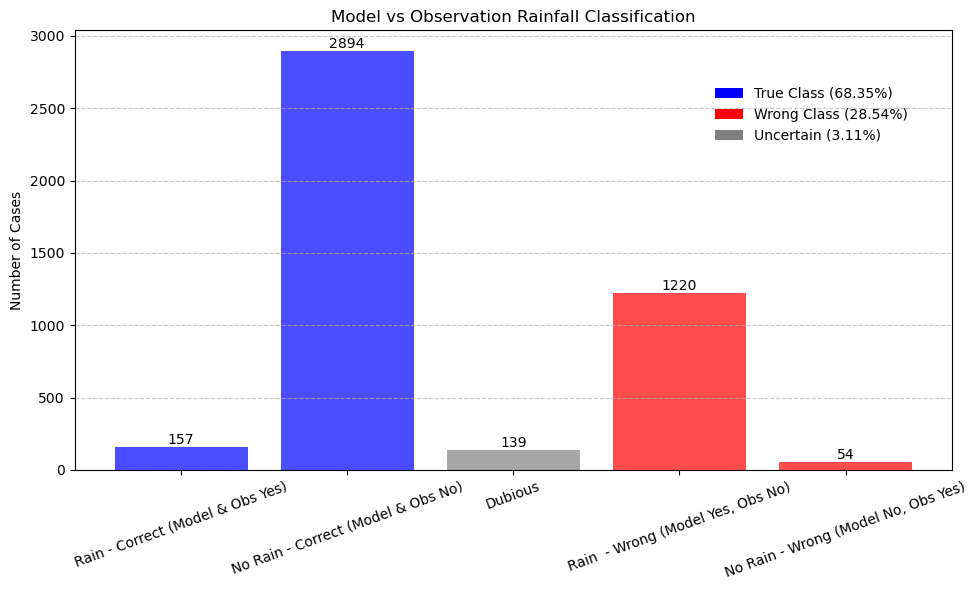

In [706]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# Define labels and values
labels = [
    'Rain - Correct (Model & Obs Yes)',
    'No Rain - Correct (Model & Obs No)',
    'Dubious',
    'Rain  - Wrong (Model Yes, Obs No)',
    'No Rain - Wrong (Model No, Obs Yes)'
]

values = [
    count_prec,
    count_no_prec,
    count_model_dubious,
    
    count_wrong_prec,
    count_wrong_zero
]

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['blue', 'blue', 'gray','red', 'red'],alpha=0.7)

# Add count labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')

legend_elements = [
    Patch(facecolor='blue', label=f'True Class ({(count_prec+count_no_prec)/4464*100:.2f}%)'),
    #Patch(facecolor='blue', label='Correct No Rain'),
    #Patch(facecolor='orange', label='Dubious Cases'),
    Patch(facecolor='red', label=f'Wrong Class ({(count_wrong_prec+count_wrong_zero)/4464*100:.2f}%)'),#label='Correct No Rain'),
    Patch(facecolor='grey', label=f'Uncertain ({(count_model_dubious)/4464*100:.2f}%)')
]

# Add the custom legend at the top
plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.84, 0.9),
           ncol=1, frameon=False)
# Formatting
plt.title("Model vs Observation Rainfall Classification")
plt.ylabel("Number of Cases")
plt.xticks(rotation=20)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


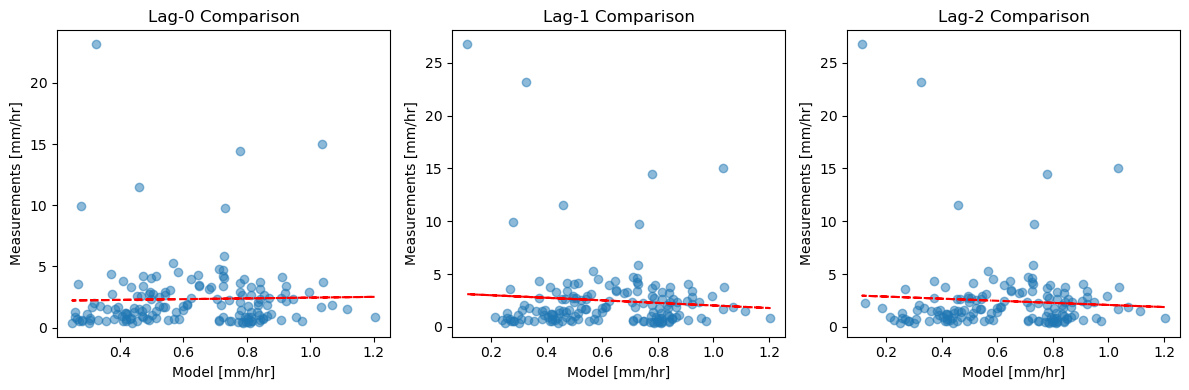

In [750]:
import matplotlib.pyplot as plt

# Prepare indices
indices     = np.where((rain_rate > 0.38) & (P * 3600 > 0.25))
indices_1   = np.where((rain_rate[0:-1] > 0.38) & (P[1:] * 3600 > 0.25))
indices_2   = np.where((rain_rate[0:-2] > 0.38) & (P[2:] * 3600 > 0.25))

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=False)

# Panel 1: Lag 0
z_0 = np.polyfit(P[indices] * 3600, rain_rate[indices], 1)
p_0 = np.poly1d(z_0)
axes[0].scatter(P[indices] * 3600, rain_rate[indices], alpha=0.5)
axes[0].plot(P[indices] * 3600, p_0(P[indices] * 3600), "r--")
axes[0].set_title('Lag-0 Comparison')
axes[0].set_xlabel('Model [mm/hr]')
axes[0].set_ylabel('Measurements [mm/hr]')

# Panel 2: Lag -1 (measurement leads model by 1)
z_1 = np.polyfit(P[indices_1] * 3600, rain_rate[indices_1], 1)
p_1 = np.poly1d(z_1)
axes[1].scatter(P[indices_1] * 3600, rain_rate[0:-1][indices_1], alpha=0.5)
axes[1].plot(P[indices_1] * 3600, p_1(P[indices_1] * 3600), "r--")
axes[1].set_title('Lag-1 Comparison')
axes[1].set_xlabel('Model [mm/hr]')
axes[1].set_ylabel('Measurements [mm/hr]')

# Panel 3: Lag +1 (model leads measurement by 1)
z_2 = np.polyfit(P[indices_2] * 3600, rain_rate[indices_2], 1)
p_2 = np.poly1d(z_2)
axes[2].scatter(P[indices_2] * 3600, rain_rate[0:-2][indices_2], alpha=0.5)
axes[2].plot(P[indices_2] * 3600, p_2(P[indices_2] * 3600), "r--")
axes[2].set_title('Lag-2 Comparison')
axes[2].set_xlabel('Model [mm/hr]')
axes[2].set_ylabel('Measurements [mm/hr]')

# Optional: consistent y-axis or limits
# for ax in axes:
#     ax.set_ylim(0, 10)
#     ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()

#plt.ylim(0,10)

In [754]:
pearsonr((rain_rate>0.38),(P*3600>0.25))

PearsonRResult(statistic=0.20650359018880848, pvalue=3.429520934379956e-44)

In [570]:
count_no_prec

<xarray.DataArray 'rainfall_rate_32bit' ()> Size: 4B
array(2780)

In [613]:
correlation = signal.correlate(rain_rate, P*3600, mode="full")

lags = signal.correlation_lags(rain_rate.size, P.size, mode="full")

lag = lags[np.argmax(correlation)]

In [721]:
print(np.array(correlation))

[ 1.39652756e-07  4.40390071e-07  7.50952897e-07 ... -1.12172320e-06
 -1.19532343e-06 -1.22798479e-06]


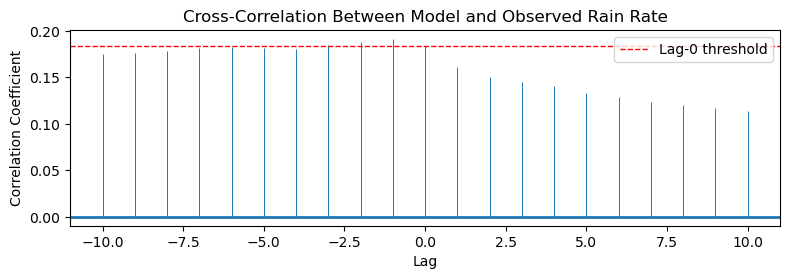

In [714]:
import matplotlib.pyplot as plt

# Create the figure and axis
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(211)

# Cross-correlation
ax1.xcorr(rain_rate, P * 3600, usevlines=True,
          maxlags=10, normed=True,
          lw=2, linewidth=0.7)

# Horizontal reference line
ax1.axhline(y=0.18337568, color='r', linestyle='dashed', linewidth=1, label='Lag-0 threshold')

# Axis labels and title
ax1.set_title('Cross-Correlation Between Model and Observed Rain Rate')
ax1.set_xlabel('Lag')
ax1.set_ylabel('Correlation Coefficient')

# Add legend
ax1.legend(loc='upper right')

# Optional: adjust layout
plt.tight_layout()
plt.show()


ValueError: x and y must have same first dimension, but have shapes (4464,) and (432,)

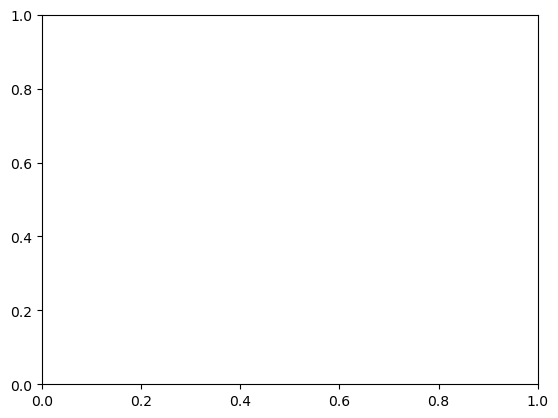

In [512]:
plt.plot(t_step,rain_rate.sel(time=slice('2024-07-05 00:00:00', '2024-07-07 23:59:00')),label='observation')

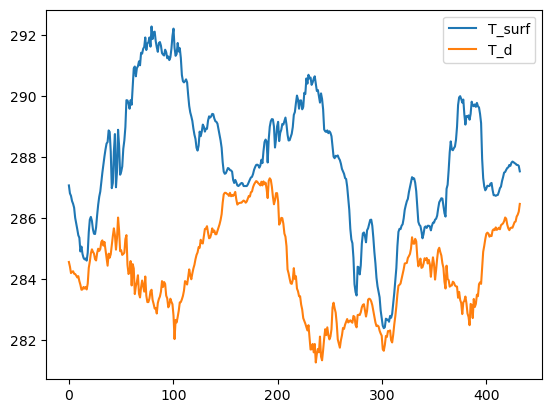

In [ ]:
plt.plot(t_step,T_surf,label='T_surf')
plt.plot(t_step,T_d_arr,label='T_d')
plt.legend()

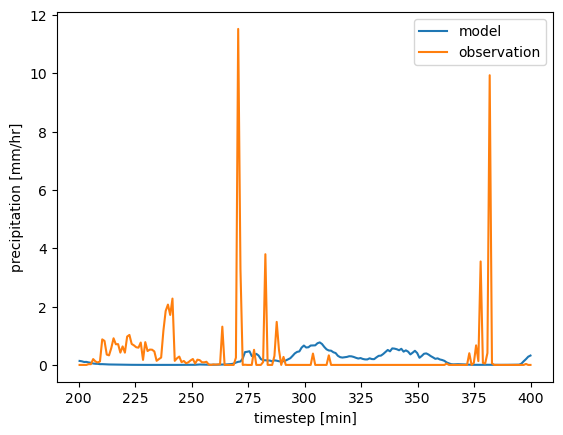

In [ ]:
#zooming when no rain is observed

t_step = np.linspace(0,len(P),len(P))
plt.plot(t_step[200:400],P[200:400]*3600,label='model')
plt.plot(t_step[200:400],rain_rate.sel(time=slice('2024-07-05 00:00:00', '2024-07-07 23:59:00'))[200:400],label='observation')
plt.legend()
plt.xlabel('timestep [min]')
plt.ylabel('precipitation [mm/hr]')
plt.show()


Text(0, 0.5, 'liquid water [kg/m^2]')

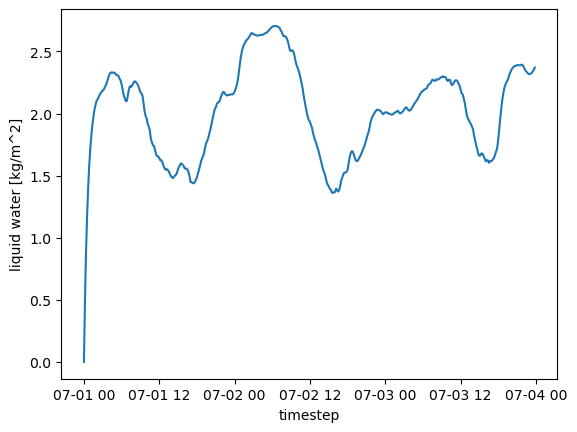

In [ ]:
#state evolution

plt.plot(measurements_used.time,X)
#plt.plot(july.time,july.lwp)
plt.xlabel('timestep')
plt.ylabel('liquid water [kg/m^2]')

Text(0, 0.5, 'average hourly precipitation (mm/hr)')

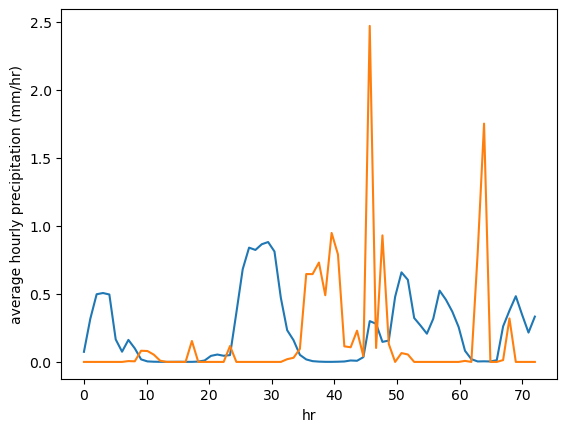

In [ ]:
Pmeas = rain_rate.sel(time=slice('2024-07-05 00:00:00', '2024-07-07 23:59:00'))
averages_P = [np.mean(P[i:i+6]) for i in range(0, len(P), 6)]
averages_Pmeas=[np.mean(Pmeas[i:i+6]) for i in range(0, len(P), 6)]
t_hr = np.linspace(0,len(averages_P),len(averages_P))

plt.plot(t_hr,np.array(averages_P)*3600,label='model (Kf)')   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(t_hr,averages_Pmeas,label='observation')
plt.xlabel('hr')
plt.ylabel('average hourly precipitation (mm/hr)')

In [ ]:
v_arr = np.zeros(len(T_surf))
O_b_arr = np.zeros(len(T_surf))
O_h_arr = np.zeros(len(T_surf))
I_arr = np.zeros(len(T_surf))

for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = variables(T_0, T_d, p_0, obs=False).run()
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)*5
    v_arr[i] = v_updr
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
    print(non_dim_numbers(v_updr)[1])
    O_b_arr[i] = O_b*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    O_h_arr[i] = O_t*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    I_arr[i] = f(T_d,p_0,p_t,T_t,rho,v_updr)
     


2.861678495997993
2.8592679795489375
2.850955763799069
2.8557801536540404
2.858272230481497
2.856799343946523
2.8620726801773095
2.8628237671576504
2.8632645505356322
2.868506832716003
2.862414917763598
2.8643715629796858
2.8542271062454567
2.8587080445089583
2.8646032444141807
2.863100768499363
2.8649348069522125
2.8623637577984007
2.8669003691811596
2.879391186295834
2.881746501465455
2.8926424873080445
2.900806511249578
2.9019186702723085
2.9015168228761086
2.893482700136438
2.8879430166321924
2.892201492563092
2.8928219548620437
2.885132426389541
2.884947573766136
2.8900008840880274
2.8871039595394357
2.874588056360593
2.875553803920708
2.859893041536245
2.843920264695285
2.831480912221156
2.8428005873000686
2.8377312249308804
2.8544746268505246
2.890033052252707
2.899957783208608
2.893273838166988
2.8729558350203215
2.8823520108758114
2.8906499002718133
2.8966426228124753
2.886674668351837
2.8730779113001677
2.8727675204546252
2.8627670001225702
2.8538635253049933
2.85084319709035

KeyboardInterrupt: 

Text(0, 0.5, 'updraft velocity [m/s]')

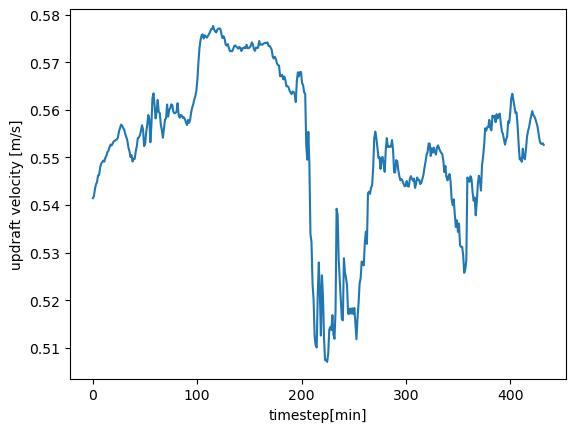

In [ ]:
plt.plot(t_step,v_arr)
plt.xlabel('timestep[min]')
plt.ylabel('updraft velocity [m/s]')

Text(0.5, 1.0, 'Cloud Fluxes')

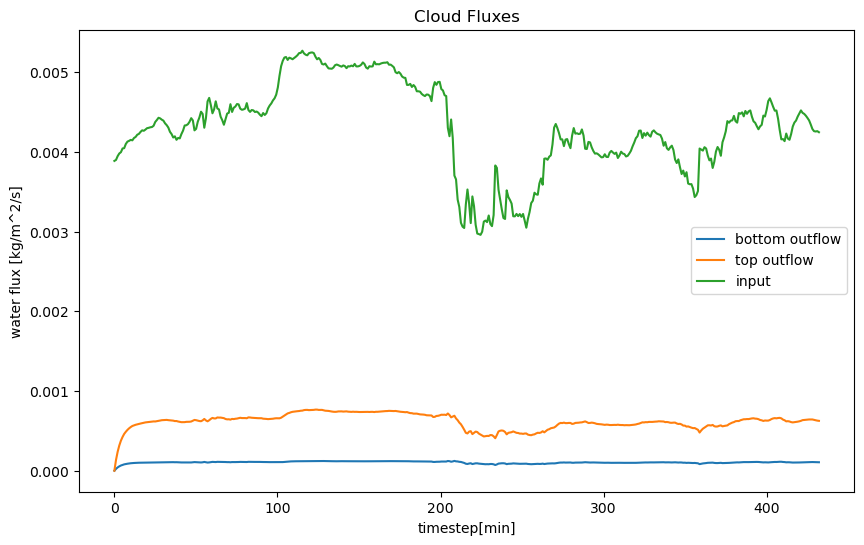

In [ ]:
A = np.zeros(30000)
#for i in range(0,3000):
    #if measurements['rain_rate'].values[7000+i]>0:
        #A[i] = t_step[i]
    #else:
        #A[i] = 0
    

plt.figure(figsize=(10,6))
plt.plot(t_step,O_b_arr,label='bottom outflow')
plt.plot(t_step,O_h_arr,label='top outflow')
plt.plot(t_step,I_arr,label='input')
plt.xlabel('timestep[min]')
plt.ylabel('water flux [kg/m^2/s]')
#plt.vlines(A,0,0.005,alpha=0.1,color='red')
plt.legend()
plt.title('Cloud Fluxes')

In [ ]:
O_b

0.3511910208066662

In [ ]:
X[i]*non_dim_numbers(v_updr)[0]/Z_c

array([0.00030251])

In [ ]:
T_t

array([246.24067734])